# 🌍 Global Market Analysis — Indian Investor Perspective
**Comparing 10 global equity markets: Returns, P/E, CAPE, Volatility, and Forecasting**

---
**Methodology:**
- Index data sourced from `all_pe_cape.xlsx`
- Currency data (INR/USD + USD/local) fetched from **Yahoo Finance**
- Total return = Index return + Currency return (INR terms)
- All analysis is data-driven; no manual calculations

## 1. 📦 Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import yfinance as yf
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
from scipy import stats
from scipy.stats import spearmanr
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap

pio.templates.default = 'plotly_white'

# Color palette for 10 countries
COUNTRY_COLORS = {
    'USA':          '#2196F3',
    'UK':           '#9C27B0',
    'TAIWAN':       '#00BCD4',
    'INDONASIA':    '#FF9800',
    'INDIA':        '#F44336',
    'CHINA':        '#E91E63',
    'SOUTH AFRICA': '#4CAF50',
    'BRAZIL':       '#009688',
    'SOUTH KOREA':  '#3F51B5',
    'JAPAN':        '#FF5722',
}

COUNTRIES = list(COUNTRY_COLORS.keys())
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. 📂 Load Index Data from Excel

In [2]:
EXCEL_PATH = 'all_pe_cape.xlsx'  # Update path if needed

raw_data = {}
xl = pd.read_excel(EXCEL_PATH, sheet_name=None)

for country, df in xl.items():
    df = df.copy()
    df['Month'] = pd.to_datetime(df['Month'])
    df = df.sort_values('Month').reset_index(drop=True)
    df.rename(columns={'Monthly Return': 'Index_Level'}, inplace=True)
    # Compute monthly index return %
    df['Index_Return_Pct'] = df['Index_Level'].pct_change() * 100
    raw_data[country] = df

print('Countries loaded:', list(raw_data.keys()))
print('Date range:', raw_data['INDIA']['Month'].min(), '→', raw_data['INDIA']['Month'].max())
raw_data['INDIA'].head()

Countries loaded: ['USA', 'UK', 'TAIWAN', 'INDONASIA', 'INDIA', 'CHINA', 'SOUTH AFRICA', 'BRAZIL', 'SOUTH KOREA', 'JAPAN']
Date range: 2020-01-01 00:00:00 → 2026-06-01 00:00:00


,Month,Index_Level,P/E,CAPE,Index_Return_Pct
0,2020-01-01,12182.50,28.3,25.80,NaN
1,2020-02-01,11962.10,27.8,25.30,-1.809152
2,2020-03-01,11201.75,25.1,22.90,-6.356325
3,2020-04-01,8597.75,19.3,17.65,-23.246368
4,2020-05-01,9859.90,21.1,19.20,14.680003


## 3. 💱 Fetch Currency Data from Yahoo Finance

For each foreign country we need:
- **INR/USD** rate (how many INR per 1 USD)
- **USD/LocalCurrency** rate (to convert index to USD, then to INR)

**Logic:** `INR Value = Index_Level / (LocalCurrency per USD) * (INR per USD)`

In [3]:
# Yahoo Finance ticker for each country's currency vs USD
# These are units of LOCAL CURRENCY per 1 USD
FX_TICKERS = {
    'USA':          None,          # Index already in USD
    'UK':           'GBPUSD=X',    # GBP per USD → invert to get USD per GBP
    'TAIWAN':       'TWD=X',       # TWD per USD
    'INDONASIA':    'IDR=X',       # IDR per USD
    'INDIA':        None,          # Home country — no conversion needed
    'CHINA':        'CNY=X',       # CNY per USD
    'SOUTH AFRICA': 'ZAR=X',       # ZAR per USD
    'BRAZIL':       'BRL=X',       # BRL per USD
    'SOUTH KOREA':  'KRW=X',       # KRW per USD
    'JAPAN':        'JPY=X',       # JPY per USD
}

# INR per USD
INR_TICKER = 'INR=X'

START = '2020-01-01'
END   = '2026-06-30'

print('Fetching INR/USD ...')
inr_raw = yf.download(INR_TICKER, start=START, end=END, interval='1mo', auto_adjust=True, progress=False)
inr_raw.index = inr_raw.index.to_period('M').to_timestamp()
inr_series = inr_raw['Close'].squeeze()
print(f'  INR/USD fetched: {len(inr_series)} months')

fx_data = {}
for country, ticker in FX_TICKERS.items():
    if ticker is None:
        fx_data[country] = None
        continue
    print(f'Fetching {ticker} for {country} ...')
    raw = yf.download(ticker, start=START, end=END, interval='1mo', auto_adjust=True, progress=False)
    raw.index = raw.index.to_period('M').to_timestamp()
    # For GBP/USD yfinance gives USD per GBP; we need GBP per USD → invert
    if ticker == 'GBPUSD=X':
        fx_data[country] = 1.0 / raw['Close'].squeeze()
    else:
        fx_data[country] = raw['Close'].squeeze()

print('\n✅ All currency data fetched')

Fetching INR/USD ...
  INR/USD fetched: 78 months
Fetching GBPUSD=X for UK ...
Fetching TWD=X for TAIWAN ...
Fetching IDR=X for INDONASIA ...
Fetching CNY=X for CHINA ...
Fetching ZAR=X for SOUTH AFRICA ...
Fetching BRL=X for BRAZIL ...
Fetching KRW=X for SOUTH KOREA ...
Fetching JPY=X for JAPAN ...

✅ All currency data fetched


## 4. 🔄 Build INR-Converted Returns

**Formula for each foreign market:**
```
Index_in_USD  = Index_Level / (Local per USD)
Index_in_INR  = Index_in_USD * (INR per USD)
INR_Return_%  = pct_change(Index_in_INR)
```
For India (home): monthly return is just `pct_change(Nifty_Level)` — no currency adjustment.

For USA: index is already in USD → `Index_in_INR = Index_Level * (INR per USD)`

In [4]:
combined = {}   # country → DataFrame with Month, Index_Level, P/E, CAPE, INR_Return_Pct

for country in COUNTRIES:
    df = raw_data[country].copy().set_index('Month')

    if country == 'INDIA':
        # Home market — just use local index return
        df['INR_Index'] = df['Index_Level']

    elif country == 'USA':
        # USD index → multiply by INR/USD
        inr_aligned = inr_series.reindex(df.index, method='nearest')
        df['INR_Index'] = df['Index_Level'] * inr_aligned

    else:
        # Foreign index in local currency → convert to USD → convert to INR
        fx_aligned  = fx_data[country].reindex(df.index, method='nearest')   # local per USD
        inr_aligned = inr_series.reindex(df.index, method='nearest')          # INR per USD
        df['USD_Index'] = df['Index_Level'] / fx_aligned
        df['INR_Index'] = df['USD_Index'] * inr_aligned

    df['INR_Return_Pct'] = df['INR_Index'].pct_change() * 100
    combined[country] = df.reset_index()

print('✅ INR-adjusted returns computed for all countries')
combined['USA'][['Month','Index_Level','INR_Index','INR_Return_Pct']].head()

✅ INR-adjusted returns computed for all countries


,Month,Index_Level,INR_Index,INR_Return_Pct
0,2020-01-01,3225.520020,231076.252264,NaN
1,2020-02-01,2954.219971,213146.975415,-7.759030
2,2020-03-01,2584.590088,194878.096579,-8.571024
3,2020-04-01,2912.429932,219185.105549,12.472930
4,2020-05-01,3044.310059,229885.590854,4.881940


## 5. 📅 Year-on-Year Return Analysis (INR Terms)

For each calendar year, we compute the **total return** using the INR-adjusted index level (first vs last month of the year).

In [5]:
def calc_yearly_return(df, country):
    """Calculate annual return for a country using INR_Index levels."""
    df = df.copy()
    df['Year'] = df['Month'].dt.year
    df = df.dropna(subset=['INR_Index'])
    rows = []
    for year, grp in df.groupby('Year'):
        grp = grp.sort_values('Month')
        start_val = grp['INR_Index'].iloc[0]
        end_val   = grp['INR_Index'].iloc[-1]
        ret = (end_val / start_val - 1) * 100
        rows.append({'Year': year, 'Country': country, 'Annual_Return_Pct': round(ret, 2)})
    return pd.DataFrame(rows)

yearly_list = []
for country in COUNTRIES:
    yearly_list.append(calc_yearly_return(combined[country], country))

yearly_df = pd.concat(yearly_list, ignore_index=True)

# Pivot for easy reading
yearly_pivot = yearly_df.pivot(index='Country', columns='Year', values='Annual_Return_Pct')
yearly_pivot.columns.name = None
print('\n📊 Year-on-Year Returns (INR-Adjusted %):')
yearly_pivot.style.format('{:.1f}%').background_gradient(cmap='RdYlGn', axis=1)


📊 Year-on-Year Returns (INR-Adjusted %):


,2020,2021,2022,2023,2024,2025,2026
Country,,,,,,,
BRAZIL,-21.4%,-14.3%,20.0%,27.6%,-22.6%,39.7%,9.7%
CHINA,30.9%,-4.5%,-20.8%,-13.0%,14.7%,26.2%,5.7%
INDIA,7.6%,21.1%,8.4%,11.4%,12.5%,10.3%,-6.6%
INDONASIA,-8.3%,6.8%,7.8%,1.3%,-2.5%,20.4%,-31.4%
JAPAN,24.4%,-4.8%,-6.6%,21.4%,12.1%,28.0%,27.6%
SOUTH AFRICA,23.9%,-9.7%,-21.2%,-13.4%,18.1%,37.6%,0.6%
SOUTH KOREA,35.1%,-5.6%,-12.4%,8.1%,-14.2%,69.8%,99.6%
TAIWAN,-45.4%,13.5%,-20.6%,-14.1%,4.3%,-25.5%,12.3%
UK,-11.7%,9.9%,1.9%,5.1%,9.2%,17.2%,0.4%


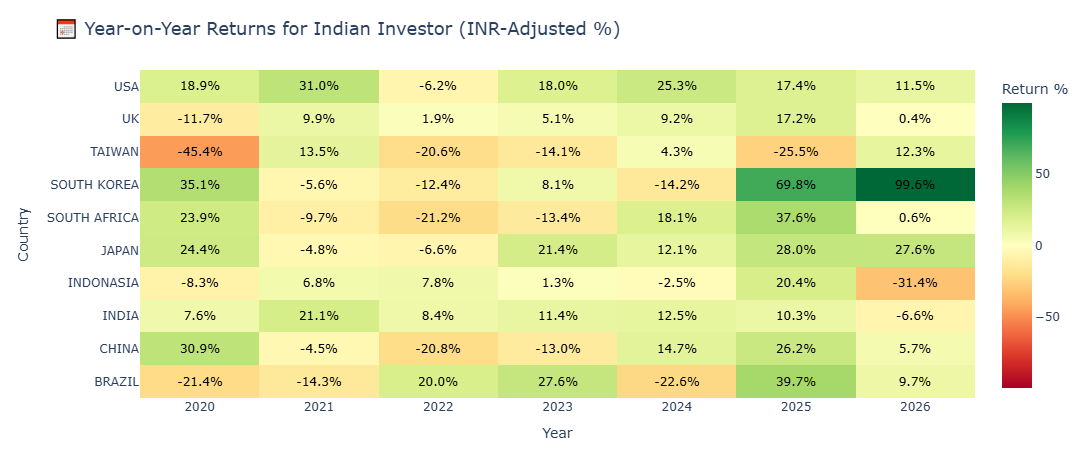

In [6]:
# ---- Heatmap: Year-on-Year Returns ----
fig = go.Figure(data=go.Heatmap(
    z=yearly_pivot.values,
    x=[str(c) for c in yearly_pivot.columns],
    y=yearly_pivot.index.tolist(),
    colorscale='RdYlGn',
    zmid=0,
    text=[[f'{v:.1f}%' for v in row] for row in yearly_pivot.values],
    texttemplate='%{text}',
    textfont={'size': 12, 'color': 'black'},
    showscale=True,
    colorbar=dict(title='Return %')
))
fig.update_layout(
    title=dict(text='📅 Year-on-Year Returns for Indian Investor (INR-Adjusted %)', font=dict(size=18)),
    xaxis_title='Year',
    yaxis_title='Country',
    height=450,
    margin=dict(l=140, r=40, t=70, b=50)
)
fig.show()

## 6. 🏆 Total Return Summary Table (Full Period)

In [7]:
summary_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index']).sort_values('Month')
    start_val = df['INR_Index'].iloc[0]
    end_val   = df['INR_Index'].iloc[-1]
    total_ret = (end_val / start_val - 1) * 100

    # Annualised return (CAGR)
    n_years = (df['Month'].iloc[-1] - df['Month'].iloc[0]).days / 365.25
    cagr = ((end_val / start_val) ** (1 / n_years) - 1) * 100

    # Volatility (std of monthly INR returns, annualised)
    monthly_ret = df['INR_Return_Pct'].dropna()
    vol = monthly_ret.std() * np.sqrt(12)

    # Sharpe-like ratio (CAGR / Annualised Vol)
    sharpe = cagr / vol if vol > 0 else np.nan

    # Max drawdown on INR_Index
    rolling_max = df['INR_Index'].cummax()
    drawdown = (df['INR_Index'] - rolling_max) / rolling_max * 100
    max_dd = drawdown.min()

    summary_rows.append({
        'Country':          country,
        'Total Return (%)': round(total_ret, 1),
        'CAGR (%)':         round(cagr, 1),
        'Ann. Volatility (%)': round(vol, 1),
        'Return/Risk':      round(sharpe, 2),
        'Max Drawdown (%)': round(max_dd, 1),
        'Period':           f"{df['Month'].iloc[0].strftime('%b %Y')} – {df['Month'].iloc[-1].strftime('%b %Y')}"
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Total Return (%)', ascending=False).reset_index(drop=True)
print('\n🏆 Total Return Summary (INR-Adjusted, Full Period):')
summary_df.style.format({
    'Total Return (%)': '{:.1f}%',
    'CAGR (%)': '{:.1f}%',
    'Ann. Volatility (%)': '{:.1f}%',
    'Return/Risk': '{:.2f}',
    'Max Drawdown (%)': '{:.1f}%',
}).background_gradient(subset=['Total Return (%)', 'CAGR (%)'], cmap='RdYlGn')


🏆 Total Return Summary (INR-Adjusted, Full Period):


,Country,Total Return (%),CAGR (%),Ann. Volatility (%),Return/Risk,Max Drawdown (%),Period
0,SOUTH KOREA,314.4%,24.8%,26.5%,0.93,-39.7%,Jan 2020 – Jun 2026
1,USA,207.0%,19.1%,16.1%,1.19,-17.6%,Jan 2020 – Jun 2026
2,JAPAN,156.7%,15.8%,20.4%,0.78,-27.1%,Jan 2020 – Jun 2026
3,INDIA,100.5%,11.5%,16.9%,0.68,-29.4%,Jan 2020 – Jun 2026
4,BRAZIL,59.9%,7.6%,27.9%,0.27,-47.2%,Jan 2020 – Jun 2026
5,UK,55.2%,7.1%,13.3%,0.53,-24.7%,Jan 2020 – Jun 2026
6,CHINA,53.2%,6.9%,18.1%,0.38,-39.7%,Jan 2020 – Jun 2026
7,SOUTH AFRICA,33.5%,4.6%,21.8%,0.21,-48.8%,Jan 2020 – Jun 2026
8,INDONASIA,-0.5%,-0.1%,19.3%,-0.00,-33.1%,Jan 2020 – Jun 2026
9,TAIWAN,-66.4%,-15.6%,20.3%,-0.77,-73.5%,Jan 2020 – Jun 2026


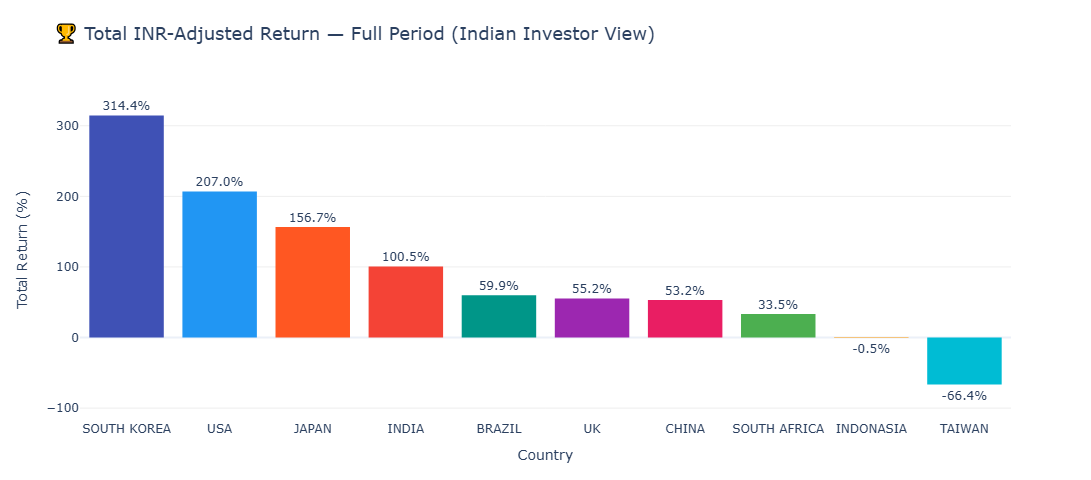

In [8]:
# ---- Bar chart: Total Return by Country ----
colors = [COUNTRY_COLORS[c] for c in summary_df['Country']]
fig = go.Figure(go.Bar(
    x=summary_df['Country'],
    y=summary_df['Total Return (%)'],
    marker_color=colors,
    text=[f"{v:.1f}%" for v in summary_df['Total Return (%)']],
    textposition='outside',
    marker_line_width=0
))
fig.update_layout(
    title=dict(text='🏆 Total INR-Adjusted Return — Full Period (Indian Investor View)', font=dict(size=18)),
    yaxis_title='Total Return (%)',
    xaxis_title='Country',
    height=480,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    showlegend=False,
    margin=dict(t=80, b=60)
)
fig.show()

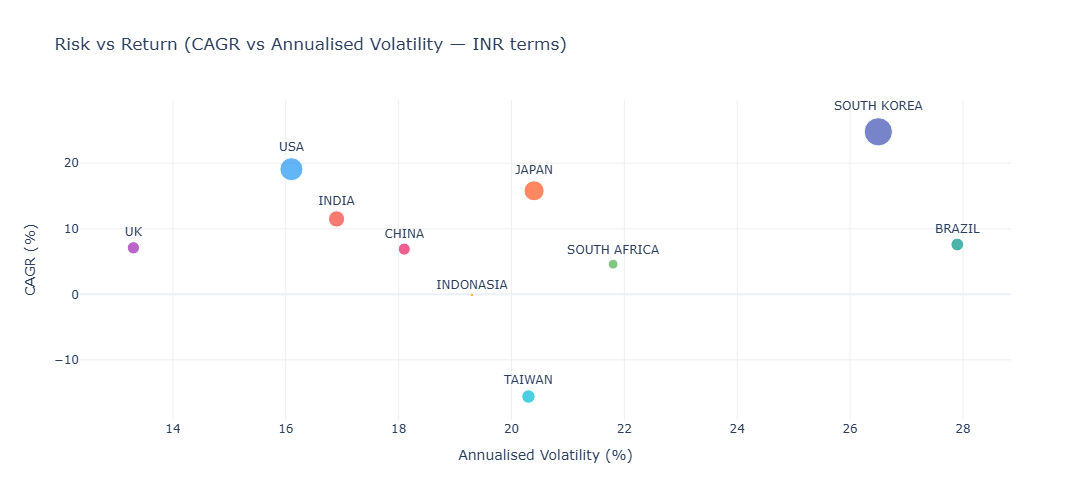

In [9]:
# ---- Risk vs Return Scatter ----
fig = px.scatter(
    summary_df,
    x='Ann. Volatility (%)',
    y='CAGR (%)',
    text='Country',
    size=[abs(v) + 5 for v in summary_df['Total Return (%)']],
    color='Country',
    color_discrete_map=COUNTRY_COLORS,
    title='Risk vs Return (CAGR vs Annualised Volatility — INR terms)',
    labels={'Ann. Volatility (%)': 'Annualised Volatility (%)', 'CAGR (%)': 'CAGR (%)'}
)
fig.update_traces(textposition='top center', marker=dict(line=dict(width=1, color='white')))
fig.update_layout(height=500, showlegend=False, title_font_size=17,
                  plot_bgcolor='rgba(0,0,0,0)', yaxis=dict(gridcolor='#eee'), xaxis=dict(gridcolor='#eee'))
fig.show()

## 7. 📈 Monthly Return % Comparison — All Countries

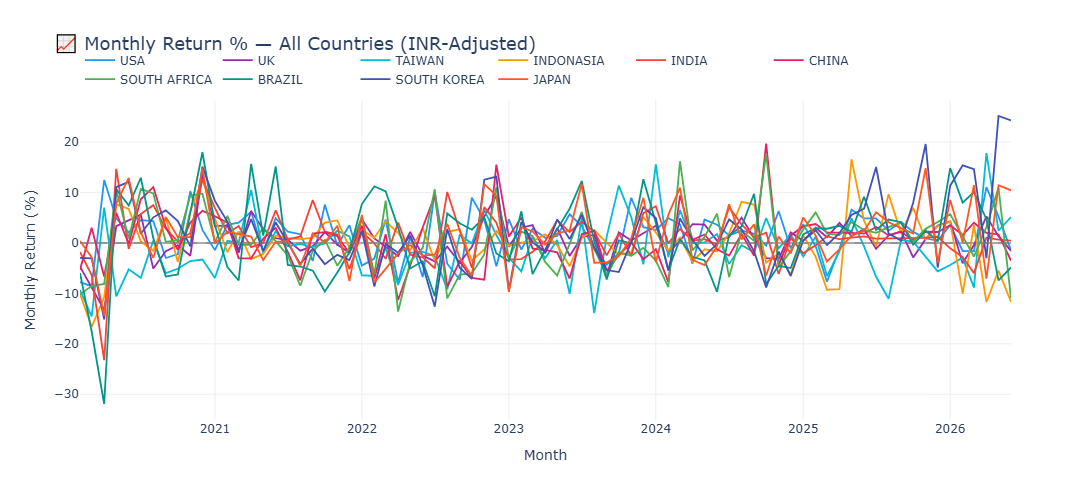

In [10]:
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct'])
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=df['INR_Return_Pct'],
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=1.8),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📈 Monthly Return % — All Countries (INR-Adjusted)', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='Monthly Return (%)',
    height=500,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee', zeroline=True, zerolinecolor='#aaa'),
    xaxis=dict(gridcolor='#eee')
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.show()

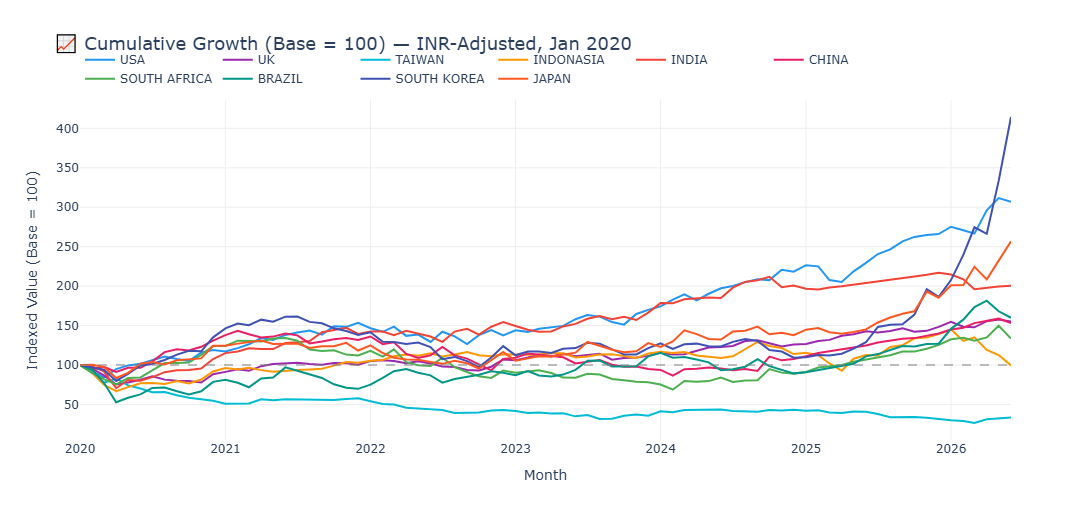

In [11]:
# ---- Normalised INR Index (base 100) — Cumulative Growth ----
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index']).sort_values('Month')
    base = df['INR_Index'].iloc[0]
    normalized = df['INR_Index'] / base * 100
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=normalized,
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.add_hline(y=100, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    title=dict(text='📈 Cumulative Growth (Base = 100) — INR-Adjusted, Jan 2020', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='Indexed Value (Base = 100)',
    height=520,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

## 8. 📊 P/E Ratio Comparison — All Countries

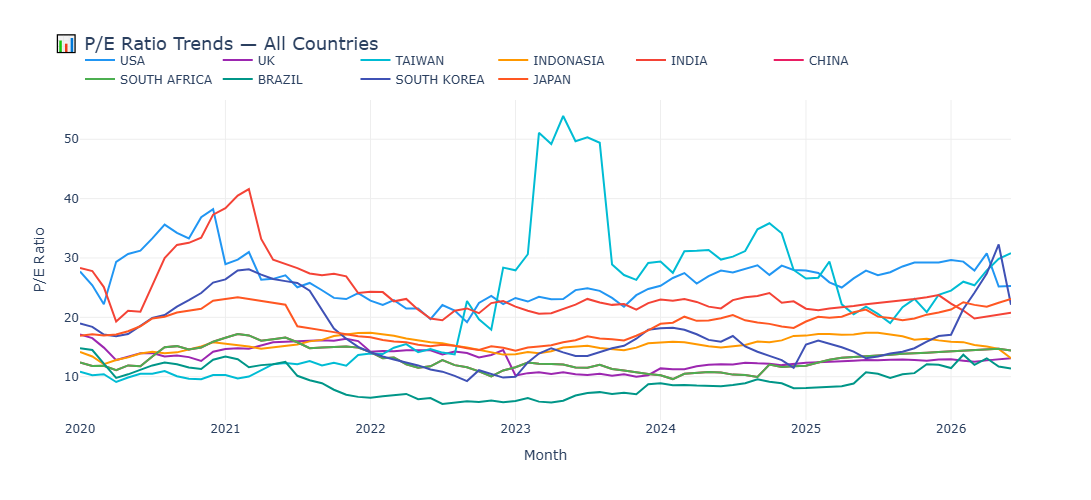

In [12]:
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['P/E'])
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=df['P/E'],
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📊 P/E Ratio Trends — All Countries', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='P/E Ratio',
    height=500,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

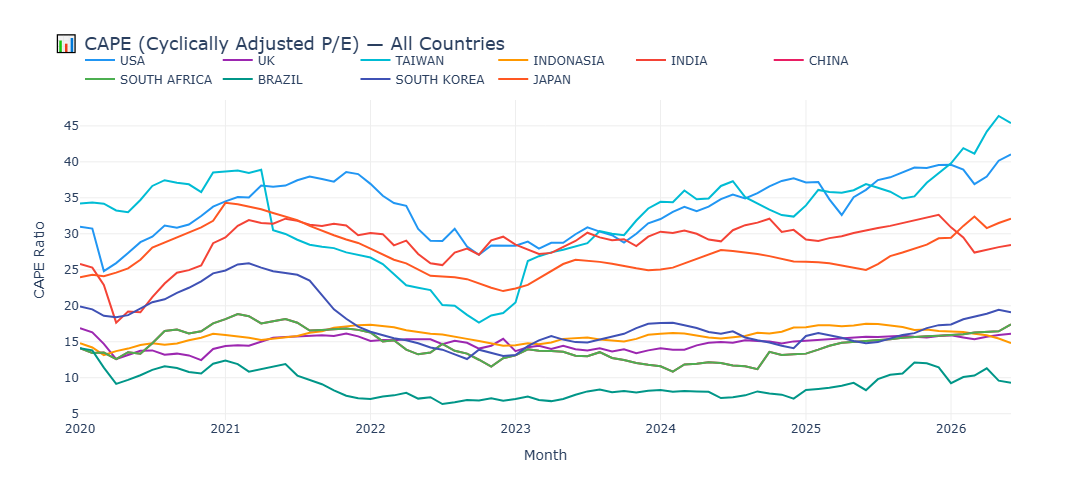

In [13]:
# ---- CAPE Comparison ----
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['CAPE'])
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=df['CAPE'],
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📊 CAPE (Cyclically Adjusted P/E) — All Countries', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='CAPE Ratio',
    height=500,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

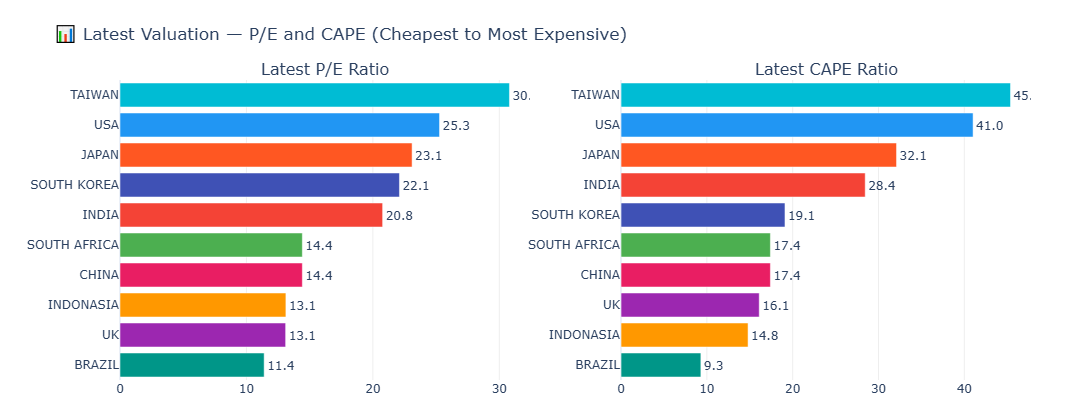

In [14]:
# ---- Latest P/E and CAPE bar chart (most recent month) ----
latest_pe   = {c: combined[c].dropna(subset=['P/E']).sort_values('Month')['P/E'].iloc[-1]   for c in COUNTRIES}
latest_cape = {c: combined[c].dropna(subset=['CAPE']).sort_values('Month')['CAPE'].iloc[-1] for c in COUNTRIES}

fig = make_subplots(rows=1, cols=2, subplot_titles=['Latest P/E Ratio', 'Latest CAPE Ratio'])

sorted_pe   = sorted(latest_pe.items(),   key=lambda x: x[1])
sorted_cape = sorted(latest_cape.items(), key=lambda x: x[1])

fig.add_trace(go.Bar(
    x=[v for _, v in sorted_pe],
    y=[c for c, _ in sorted_pe],
    orientation='h',
    marker_color=[COUNTRY_COLORS[c] for c, _ in sorted_pe],
    text=[f'{v:.1f}' for _, v in sorted_pe],
    textposition='outside',
    name='P/E'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=[v for _, v in sorted_cape],
    y=[c for c, _ in sorted_cape],
    orientation='h',
    marker_color=[COUNTRY_COLORS[c] for c, _ in sorted_cape],
    text=[f'{v:.1f}' for _, v in sorted_cape],
    textposition='outside',
    name='CAPE'
), row=1, col=2)

fig.update_layout(
    title=dict(text='📊 Latest Valuation — P/E and CAPE (Cheapest to Most Expensive)', font=dict(size=17)),
    height=420,
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=120, r=60, t=80, b=40)
)
fig.update_xaxes(gridcolor='#eee')
fig.show()

## 9. 📉 Market Volatility Analysis

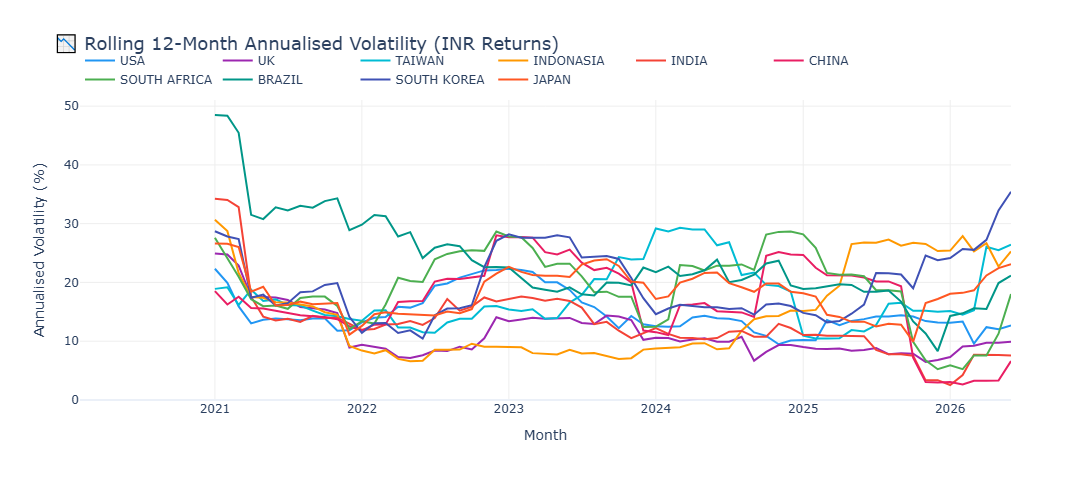

In [15]:
# Rolling 12-month annualised volatility for each country (INR returns)
fig = go.Figure()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct']).sort_values('Month')
    rolling_vol = df['INR_Return_Pct'].rolling(12).std() * np.sqrt(12)
    fig.add_trace(go.Scatter(
        x=df['Month'],
        y=rolling_vol,
        name=country,
        line=dict(color=COUNTRY_COLORS[country], width=2),
        mode='lines'
    ))

fig.update_layout(
    title=dict(text='📉 Rolling 12-Month Annualised Volatility (INR Returns)', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='Annualised Volatility (%)',
    height=480,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

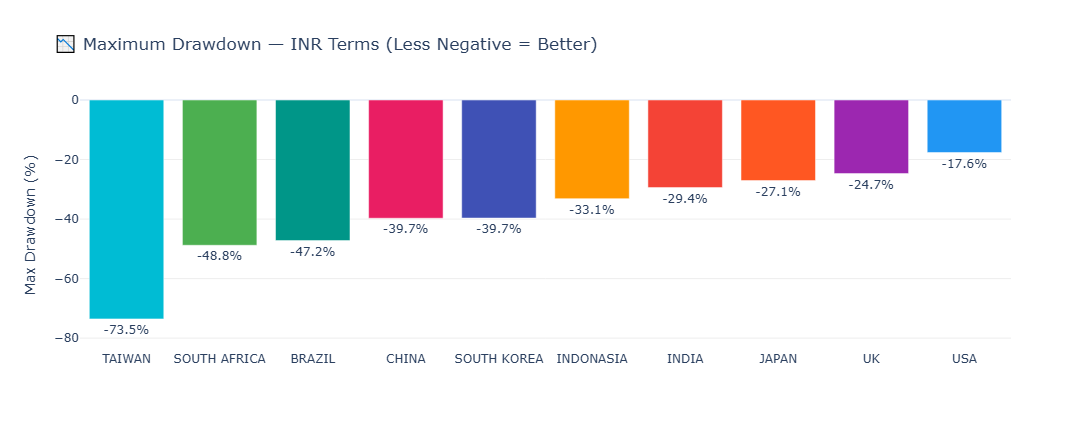

In [16]:
# ---- Max Drawdown Comparison ----
dd_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index']).sort_values('Month')
    rolling_max = df['INR_Index'].cummax()
    dd = (df['INR_Index'] - rolling_max) / rolling_max * 100
    dd_rows.append({'Country': country, 'Max_Drawdown': dd.min()})

dd_df = pd.DataFrame(dd_rows).sort_values('Max_Drawdown')

fig = go.Figure(go.Bar(
    x=dd_df['Country'],
    y=dd_df['Max_Drawdown'],
    marker_color=[COUNTRY_COLORS[c] for c in dd_df['Country']],
    text=[f'{v:.1f}%' for v in dd_df['Max_Drawdown']],
    textposition='outside'
))
fig.update_layout(
    title=dict(text='📉 Maximum Drawdown — INR Terms (Less Negative = Better)', font=dict(size=17)),
    yaxis_title='Max Drawdown (%)',
    height=430,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    showlegend=False
)
fig.show()

## 10. 🔗 Correlation Analysis: P/E, CAPE, Monthly Return

In [17]:
# Pearson and Spearman correlation between P/E and next-month return, for each country
corr_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['P/E','CAPE','INR_Return_Pct']).copy()
    df = df.sort_values('Month')
    df['Next_Month_Return'] = df['INR_Return_Pct'].shift(-1)
    df = df.dropna(subset=['Next_Month_Return'])

    for metric in ['P/E', 'CAPE']:
        pearson_r, pearson_p = stats.pearsonr(df[metric], df['Next_Month_Return'])
        spearman_r, spearman_p = spearmanr(df[metric], df['Next_Month_Return'])
        corr_rows.append({
            'Country':      country,
            'Metric':       metric,
            'Pearson_r':    round(pearson_r, 3),
            'Pearson_p':    round(pearson_p, 3),
            'Spearman_r':   round(spearman_r, 3),
            'Spearman_p':   round(spearman_p, 3)
        })

corr_df = pd.DataFrame(corr_rows)
print('📎 Correlation of P/E & CAPE with Next-Month Return:')
corr_df.style.format({'Pearson_r': '{:.3f}', 'Spearman_r': '{:.3f}'}) \
       .background_gradient(subset=['Pearson_r','Spearman_r'], cmap='RdYlGn', vmin=-0.5, vmax=0.5)

📎 Correlation of P/E & CAPE with Next-Month Return:


,Country,Metric,Pearson_r,Pearson_p,Spearman_r,Spearman_p
0,USA,P/E,0.013,0.914000,0.041,0.723000
1,USA,CAPE,-0.142,0.222000,-0.139,0.231000
2,UK,P/E,-0.183,0.113000,-0.198,0.086000
3,UK,CAPE,-0.278,0.015000,-0.232,0.044000
4,TAIWAN,P/E,0.086,0.461000,0.184,0.113000
5,TAIWAN,CAPE,0.069,0.552000,-0.031,0.792000
6,INDONASIA,P/E,0.176,0.128000,0.141,0.224000
7,INDONASIA,CAPE,0.151,0.193000,0.124,0.285000
8,INDIA,P/E,0.070,0.550000,0.018,0.880000
9,INDIA,CAPE,-0.132,0.256000,-0.130,0.263000


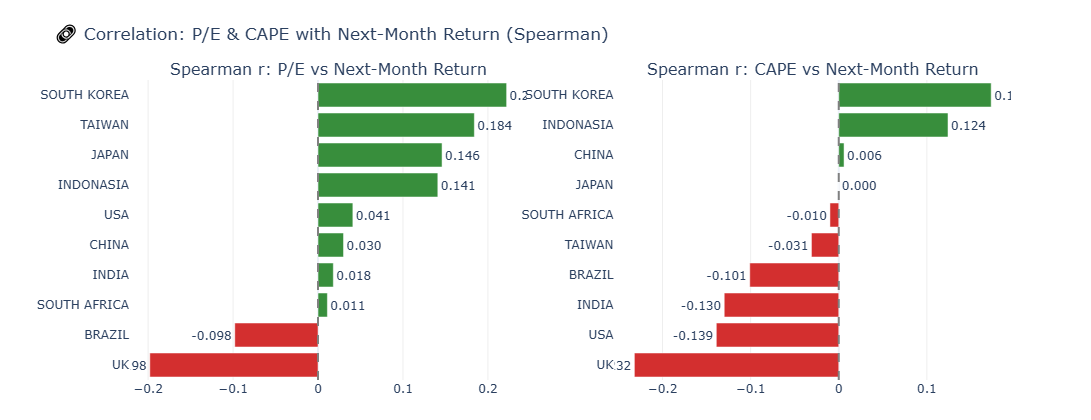

In [18]:
# ---- Correlation Heatmap: P/E with next-month return ----
pe_corr_pivot = corr_df[corr_df['Metric']=='P/E'].set_index('Country')['Spearman_r']
cape_corr_pivot = corr_df[corr_df['Metric']=='CAPE'].set_index('Country')['Spearman_r']

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['Spearman r: P/E vs Next-Month Return', 'Spearman r: CAPE vs Next-Month Return']
)

for col_idx, (series, label) in enumerate([(pe_corr_pivot, 'P/E'), (cape_corr_pivot, 'CAPE')], 1):
    sorted_s = series.sort_values()
    colors_bar = ['#d32f2f' if v < 0 else '#388e3c' for v in sorted_s.values]
    fig.add_trace(go.Bar(
        x=sorted_s.values,
        y=sorted_s.index,
        orientation='h',
        marker_color=colors_bar,
        text=[f'{v:.3f}' for v in sorted_s.values],
        textposition='outside',
        name=label
    ), row=1, col=col_idx)

fig.update_layout(
    title=dict(text='🔗 Correlation: P/E & CAPE with Next-Month Return (Spearman)', font=dict(size=17)),
    height=420,
    showlegend=False,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(l=130, r=80, t=80, b=40)
)
fig.update_xaxes(gridcolor='#eee')
fig.add_vline(x=0, line_dash='dash', line_color='gray', row=1, col=1)
fig.add_vline(x=0, line_dash='dash', line_color='gray', row=1, col=2)
fig.show()

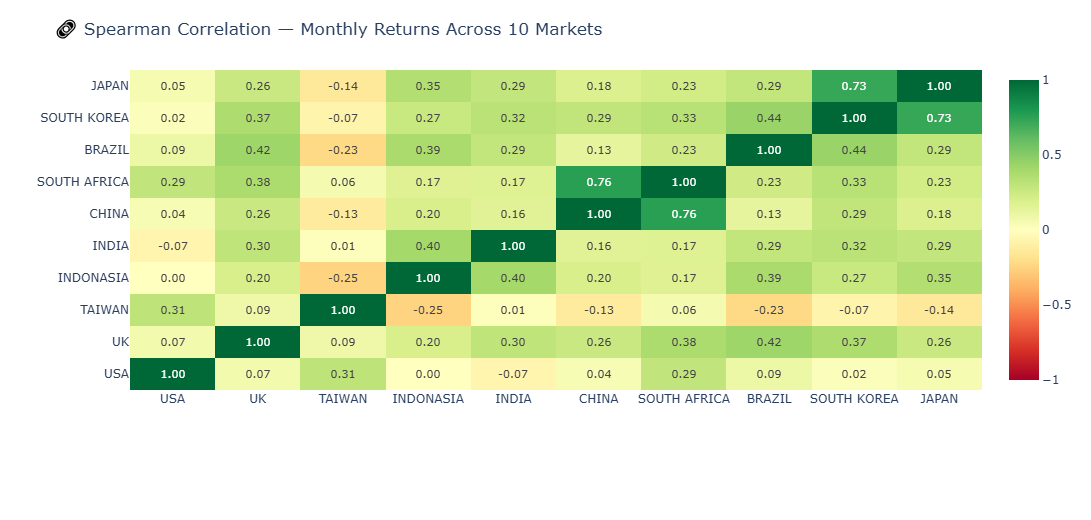

In [19]:
# ---- Cross-country correlation matrix (monthly INR returns) ----
ret_matrix = pd.DataFrame()
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Return_Pct']).set_index('Month')['INR_Return_Pct']
    ret_matrix[country] = df

corr_matrix = ret_matrix.corr(method='spearman')

fig = go.Figure(go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    colorscale='RdYlGn',
    zmin=-1, zmax=1, zmid=0,
    text=[[f'{v:.2f}' for v in row] for row in corr_matrix.values],
    texttemplate='%{text}',
    textfont={'size': 11},
    showscale=True
))
fig.update_layout(
    title=dict(text='🔗 Spearman Correlation — Monthly Returns Across 10 Markets', font=dict(size=17)),
    height=520,
    margin=dict(l=130, r=40, t=70, b=130)
)
fig.show()

## 11. 📆 Seasonal Analysis — Average Monthly Return by Calendar Month

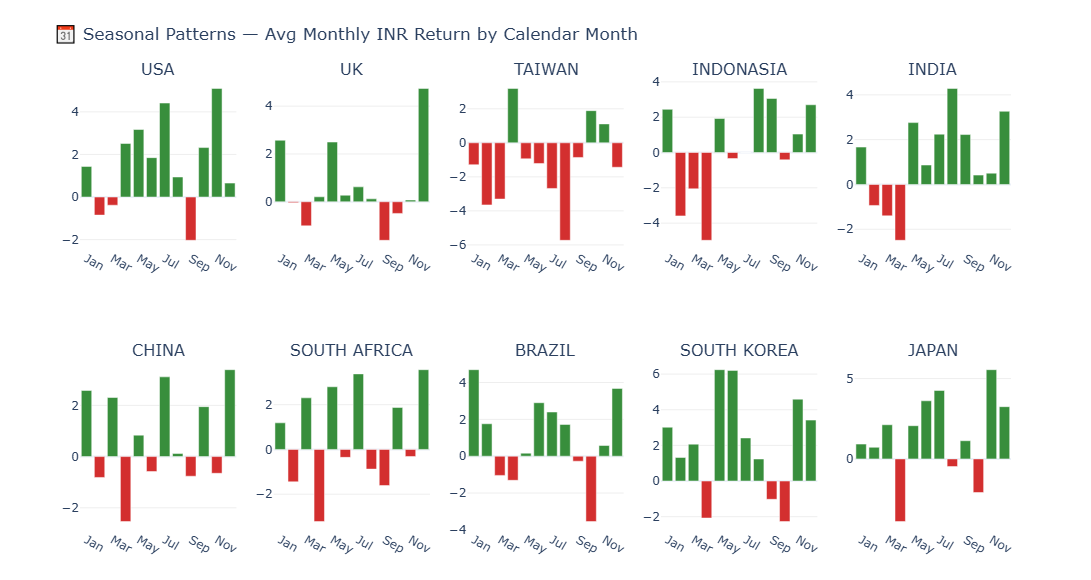

In [20]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig = make_subplots(
    rows=2, cols=5,
    subplot_titles=COUNTRIES,
    shared_yaxes=False
)

for idx, country in enumerate(COUNTRIES):
    row = idx // 5 + 1
    col = idx % 5 + 1
    df = combined[country].dropna(subset=['INR_Return_Pct']).copy()
    df['CalMonth'] = df['Month'].dt.month
    seasonal = df.groupby('CalMonth')['INR_Return_Pct'].mean()
    bar_colors = ['#d32f2f' if v < 0 else '#388e3c' for v in seasonal.values]

    fig.add_trace(go.Bar(
        x=[month_names[m-1] for m in seasonal.index],
        y=seasonal.values,
        marker_color=bar_colors,
        showlegend=False,
        name=country
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='📆 Seasonal Patterns — Avg Monthly INR Return by Calendar Month', font=dict(size=17)),
    height=580,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=80, b=50)
)
fig.update_yaxes(gridcolor='#eee')
fig.show()

## 12. 🔮 Forecasting: P/E and CAPE Trends (Holt-Winters)

C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-pa

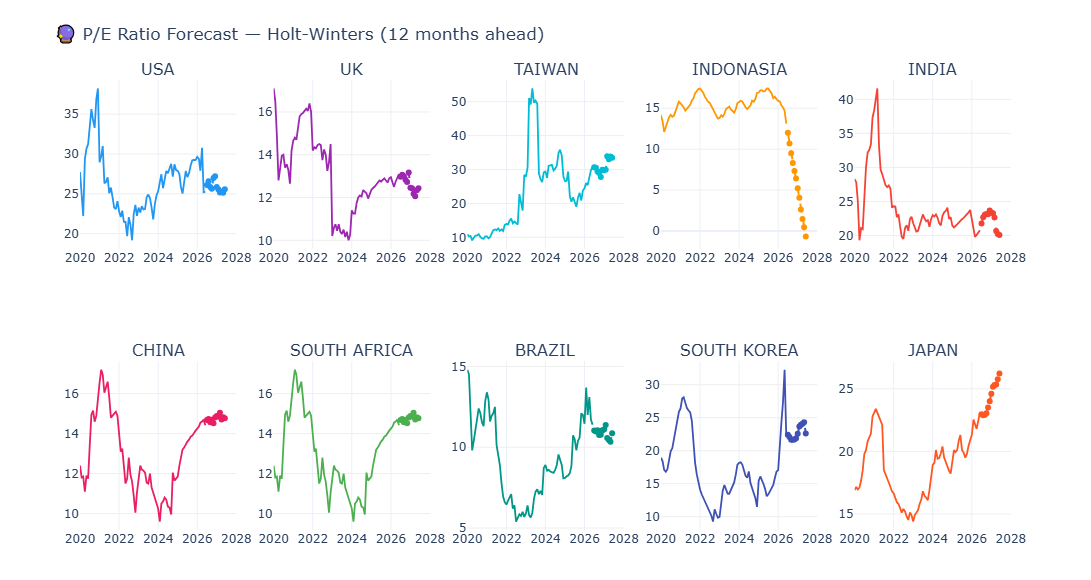

In [21]:
FORECAST_MONTHS = 12

fig = make_subplots(
    rows=2, cols=5,
    subplot_titles=COUNTRIES,
    shared_yaxes=False
)

for idx, country in enumerate(COUNTRIES):
    row = idx // 5 + 1
    col = idx % 5 + 1
    df = combined[country].dropna(subset=['P/E']).sort_values('Month')
    series = df.set_index('Month')['P/E']

    # Holt-Winters exponential smoothing
    try:
        model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
    except Exception:
        model = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)

    color = COUNTRY_COLORS[country]

    # Historical
    fig.add_trace(go.Scatter(
        x=series.index, y=series.values,
        line=dict(color=color, width=1.8),
        showlegend=False, name=f'{country} Actual'
    ), row=row, col=col)

    # Forecast
    fig.add_trace(go.Scatter(
        x=forecast.index, y=forecast.values,
        line=dict(color=color, dash='dash', width=2),
        showlegend=False, name=f'{country} Forecast'
    ), row=row, col=col)

fig.update_layout(
    title=dict(text='🔮 P/E Ratio Forecast — Holt-Winters (12 months ahead)', font=dict(size=17)),
    height=580,
    plot_bgcolor='rgba(0,0,0,0)',
    margin=dict(t=80, b=50)
)
fig.update_yaxes(gridcolor='#eee')
fig.show()

C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Dell\Lib\site-pa

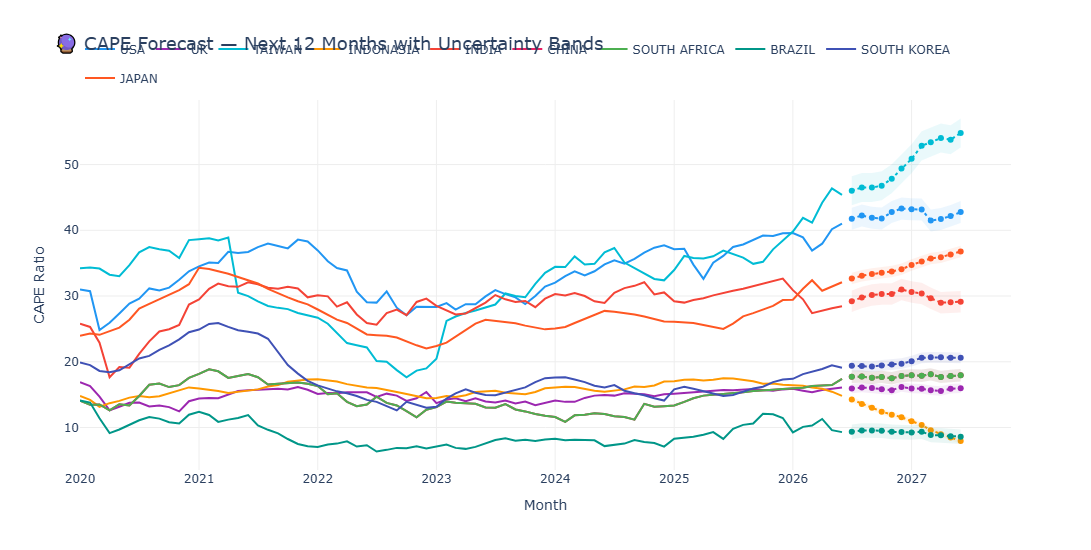

In [22]:
# ---- CAPE Forecasts with uncertainty bands ----
fig = go.Figure()

for country in COUNTRIES:
    df = combined[country].dropna(subset=['CAPE']).sort_values('Month')
    series = df.set_index('Month')['CAPE']

    try:
        model = ExponentialSmoothing(series, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
        resid_std = model.resid.std()
    except Exception:
        model = ExponentialSmoothing(series, trend='add').fit(optimized=True)
        forecast = model.forecast(FORECAST_MONTHS)
        resid_std = model.resid.std()

    color = COUNTRY_COLORS[country]

    # Historical line
    fig.add_trace(go.Scatter(
        x=series.index, y=series.values,
        line=dict(color=color, width=2),
        name=country, legendgroup=country, showlegend=True
    ))

    # Forecast dashed
    fig.add_trace(go.Scatter(
        x=forecast.index, y=forecast.values,
        line=dict(color=color, dash='dot', width=2),
        name=f'{country} Fcast', legendgroup=country, showlegend=False
    ))

    # Uncertainty band ±1.5 std
    upper = forecast + 1.5 * resid_std
    lower = forecast - 1.5 * resid_std
    fig.add_trace(go.Scatter(
        x=list(forecast.index) + list(forecast.index[::-1]),
        y=list(upper.values) + list(lower.values[::-1]),
        fill='toself',
        fillcolor=color,
        opacity=0.08,
        line=dict(color='rgba(0,0,0,0)'),
        showlegend=False, legendgroup=country
    ))

fig.update_layout(
    title=dict(text='🔮 CAPE Forecast — Next 12 Months with Uncertainty Bands', font=dict(size=18)),
    xaxis_title='Month',
    yaxis_title='CAPE Ratio',
    height=550,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02),
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee')
)
fig.show()

## 13. 🏅 Best Market Scorecard — Last 5 Years

In [23]:
cutoff_5y = pd.Timestamp.now() - pd.DateOffset(years=5)

score_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index', 'P/E', 'CAPE']).copy()
    df5 = df[df['Month'] >= cutoff_5y].sort_values('Month')

    if len(df5) < 12:
        df5 = df.sort_values('Month').tail(60)

    start_val = df5['INR_Index'].iloc[0]
    end_val   = df5['INR_Index'].iloc[-1]
    n_years   = (df5['Month'].iloc[-1] - df5['Month'].iloc[0]).days / 365.25
    cagr_5y   = ((end_val / start_val) ** (1 / max(n_years, 0.1)) - 1) * 100
    vol_5y    = df5['INR_Return_Pct'].dropna().std() * np.sqrt(12)
    latest_pe   = df5['P/E'].iloc[-1]
    latest_cape = df5['CAPE'].iloc[-1]
    avg_pe_5y   = df5['P/E'].mean()
    pe_vs_avg   = (latest_pe / avg_pe_5y - 1) * 100  # positive = expensive vs history

    score_rows.append({
        'Country':         country,
        '5Y CAGR (%)':     round(cagr_5y, 1),
        '5Y Volatility':   round(vol_5y, 1),
        'Latest P/E':      round(latest_pe, 1),
        'Latest CAPE':     round(latest_cape, 1),
        'P/E vs 5Y Avg (%)': round(pe_vs_avg, 1)
    })

score_df = pd.DataFrame(score_rows)

# Simple composite score: high CAGR good, high vol bad, low P/E good, low P/E vs avg good
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

score_df['S_CAGR']     = scaler.fit_transform(score_df[['5Y CAGR (%)']])
score_df['S_Vol']      = 1 - scaler.fit_transform(score_df[['5Y Volatility']])
score_df['S_PE']       = 1 - scaler.fit_transform(score_df[['Latest P/E']])
score_df['S_CAPE']     = 1 - scaler.fit_transform(score_df[['Latest CAPE']])
score_df['S_PEvsAvg']  = 1 - scaler.fit_transform(score_df[['P/E vs 5Y Avg (%)']])

score_df['Composite_Score'] = (
    score_df['S_CAGR']    * 0.35 +
    score_df['S_Vol']     * 0.20 +
    score_df['S_PE']      * 0.20 +
    score_df['S_CAPE']    * 0.15 +
    score_df['S_PEvsAvg'] * 0.10
).round(3)

display_cols = ['Country', '5Y CAGR (%)', '5Y Volatility', 'Latest P/E', 'Latest CAPE', 'P/E vs 5Y Avg (%)', 'Composite_Score']
score_display = score_df[display_cols].sort_values('Composite_Score', ascending=False).reset_index(drop=True)
print('🏅 Best Markets Scorecard — Last 5 Years:')
score_display.style.format({'5Y CAGR (%)': '{:.1f}%', '5Y Volatility': '{:.1f}%', 'Composite_Score': '{:.3f}'}) \
             .background_gradient(subset=['Composite_Score'], cmap='RdYlGn')

🏅 Best Markets Scorecard — Last 5 Years:


,Country,5Y CAGR (%),5Y Volatility,Latest P/E,Latest CAPE,P/E vs 5Y Avg (%),Composite_Score
0,UK,8.8%,10.0%,13.100000,16.100000,3.000000,0.782
1,BRAZIL,11.7%,21.3%,11.400000,9.300000,36.500000,0.671
2,INDIA,9.4%,11.9%,20.800000,28.400000,-7.900000,0.655
3,INDONASIA,1.2%,17.3%,13.100000,14.800000,-16.600000,0.651
4,USA,17.1%,15.2%,25.300000,41.000000,-0.100000,0.591
5,CHINA,2.2%,18.3%,14.400000,17.400000,15.500000,0.571
6,SOUTH KOREA,21.1%,27.2%,22.100000,19.100000,41.100000,0.549
7,JAPAN,15.3%,19.9%,23.100000,32.100000,27.200000,0.528
8,SOUTH AFRICA,0.4%,21.3%,14.400000,17.400000,15.500000,0.515
9,TAIWAN,-10.0%,19.7%,30.800000,45.400000,17.900000,0.127


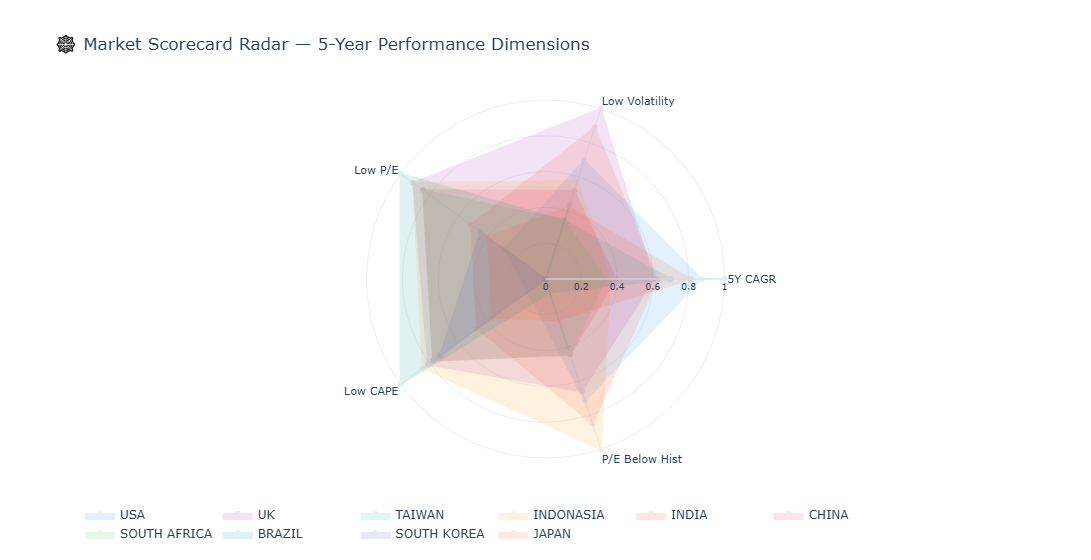

In [24]:
# ---- Radar chart: Composite scores per dimension ----
dims = ['S_CAGR', 'S_Vol', 'S_PE', 'S_CAPE', 'S_PEvsAvg']
dim_labels = ['5Y CAGR', 'Low Volatility', 'Low P/E', 'Low CAPE', 'P/E Below Hist']

fig = go.Figure()
for _, row in score_df.iterrows():
    vals = [row[d] for d in dims]
    vals_closed = vals + [vals[0]]
    labels_closed = dim_labels + [dim_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals_closed,
        theta=labels_closed,
        fill='toself',
        name=row['Country'],
        line=dict(color=COUNTRY_COLORS[row['Country']], width=2),
        fillcolor=COUNTRY_COLORS[row['Country']],
        opacity=0.12
    ))

fig.update_layout(
    title=dict(text='🕸️ Market Scorecard Radar — 5-Year Performance Dimensions', font=dict(size=17)),
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], tickfont=dict(size=9)),
        angularaxis=dict(tickfont=dict(size=11))
    ),
    showlegend=True,
    legend=dict(orientation='h', yanchor='bottom', y=-0.25),
    height=560
)
fig.show()

## 14. 🔭 2026 Trend Analysis: Which Market Looks Best for Next 6/12 Months?

In [25]:
# Use last 6 months of data to evaluate momentum and valuation
cutoff_6m = pd.Timestamp.now() - pd.DateOffset(months=6)

outlook_rows = []
for country in COUNTRIES:
    df = combined[country].dropna(subset=['INR_Index', 'P/E', 'CAPE']).sort_values('Month')
    df6m = df[df['Month'] >= cutoff_6m]

    if len(df6m) < 2:
        df6m = df.tail(6)

    # 6-month momentum
    momentum_6m = (df6m['INR_Index'].iloc[-1] / df6m['INR_Index'].iloc[0] - 1) * 100

    # PE trend (slope via linregress)
    pe_series = df6m['P/E'].dropna().values
    if len(pe_series) >= 3:
        pe_slope, *_ = np.polyfit(range(len(pe_series)), pe_series, 1)
    else:
        pe_slope = 0

    # CAPE trend
    cape_series = df6m['CAPE'].dropna().values
    if len(cape_series) >= 3:
        cape_slope, *_ = np.polyfit(range(len(cape_series)), cape_series, 1)
    else:
        cape_slope = 0

    latest_pe   = df['P/E'].iloc[-1]
    latest_cape = df['CAPE'].iloc[-1]

    outlook_rows.append({
        'Country':         country,
        '6M Momentum (%)': round(momentum_6m, 1),
        'P/E Trend':       round(pe_slope, 2),     # negative = P/E falling = valuation improving
        'CAPE Trend':      round(cape_slope, 2),
        'Latest P/E':      round(latest_pe, 1),
        'Latest CAPE':     round(latest_cape, 1)
    })

outlook_df = pd.DataFrame(outlook_rows)

# Scoring: high momentum, low valuation, falling P/E = good
outlook_df['Score_Mom']  = scaler.fit_transform(outlook_df[['6M Momentum (%)']])
outlook_df['Score_PE']   = 1 - scaler.fit_transform(outlook_df[['Latest P/E']])
outlook_df['Score_CAPE'] = 1 - scaler.fit_transform(outlook_df[['Latest CAPE']])
outlook_df['Score_PETrend'] = 1 - scaler.fit_transform(outlook_df[['P/E Trend']])  # falling P/E = good

outlook_df['Outlook_Score'] = (
    outlook_df['Score_Mom']     * 0.35 +
    outlook_df['Score_PE']      * 0.25 +
    outlook_df['Score_CAPE']    * 0.25 +
    outlook_df['Score_PETrend'] * 0.15
).round(3)

out_display = outlook_df[['Country','6M Momentum (%)','Latest P/E','Latest CAPE','P/E Trend','CAPE Trend','Outlook_Score']] \
              .sort_values('Outlook_Score', ascending=False).reset_index(drop=True)

print('🔭 6-Month Outlook Scorecard — 2026:')
out_display.style.format({'6M Momentum (%)': '{:.1f}%', 'Outlook_Score': '{:.3f}'}) \
           .background_gradient(subset=['Outlook_Score'], cmap='RdYlGn')

🔭 6-Month Outlook Scorecard — 2026:


,Country,6M Momentum (%),Latest P/E,Latest CAPE,P/E Trend,CAPE Trend,Outlook_Score
0,BRAZIL,9.6%,11.400000,9.300000,-0.150000,-0.010000,0.717
1,SOUTH KOREA,99.6%,22.100000,19.100000,1.740000,0.370000,0.644
2,UK,0.4%,13.100000,16.100000,0.050000,0.070000,0.612
3,CHINA,5.7%,14.400000,17.400000,0.060000,0.240000,0.600
4,SOUTH AFRICA,0.6%,14.400000,17.400000,0.060000,0.240000,0.586
5,INDONASIA,-31.4%,13.100000,14.800000,-0.500000,-0.310000,0.567
6,JAPAN,27.6%,23.100000,32.100000,0.240000,0.370000,0.434
7,INDIA,-6.6%,20.800000,28.400000,-0.270000,-0.450000,0.427
8,USA,11.5%,25.300000,41.000000,-0.900000,0.340000,0.366
9,TAIWAN,12.3%,30.800000,45.400000,1.300000,1.270000,0.142


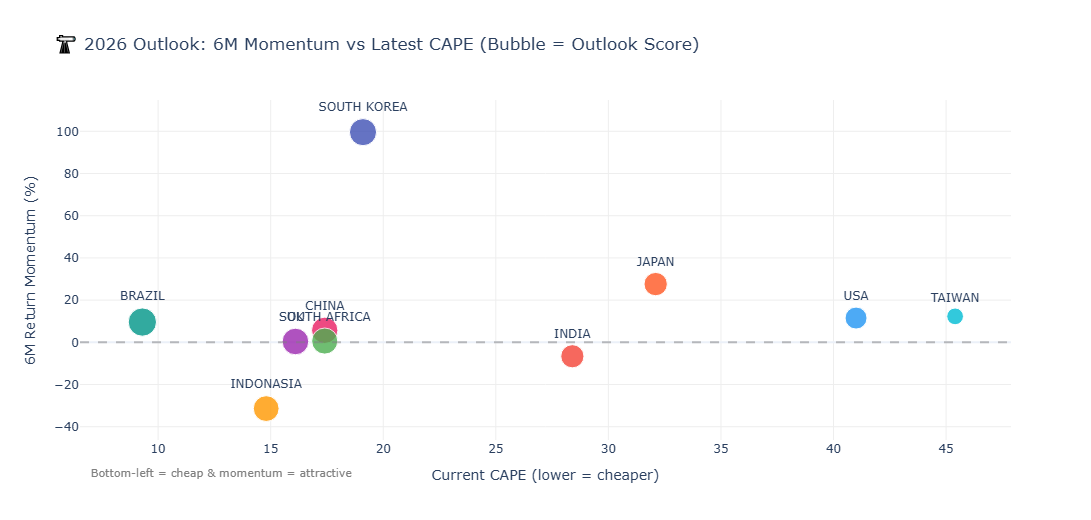

In [26]:
# ---- Bubble Chart: Momentum vs CAPE, bubble = Outlook Score ----
fig = px.scatter(
    out_display,
    x='Latest CAPE',
    y='6M Momentum (%)',
    size=[s * 60 + 10 for s in out_display['Outlook_Score']],
    color='Country',
    color_discrete_map=COUNTRY_COLORS,
    text='Country',
    title='🔭 2026 Outlook: 6M Momentum vs Latest CAPE (Bubble = Outlook Score)',
    labels={'Latest CAPE': 'Current CAPE (lower = cheaper)', '6M Momentum (%)': '6M Return Momentum (%)'}
)
fig.update_traces(textposition='top center', marker=dict(opacity=0.8, line=dict(width=1, color='white')))
fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    height=520,
    showlegend=False,
    title_font_size=17,
    plot_bgcolor='rgba(0,0,0,0)',
    xaxis=dict(gridcolor='#eee'),
    yaxis=dict(gridcolor='#eee'),
    annotations=[dict(
        text='Bottom-left = cheap & momentum = attractive',
        xref='paper', yref='paper', x=0.01, y=-0.12,
        showarrow=False, font=dict(size=11, color='gray')
    )]
)
fig.show()

## 15. 📊 Year-on-Year Bar Chart — Grouped by Country

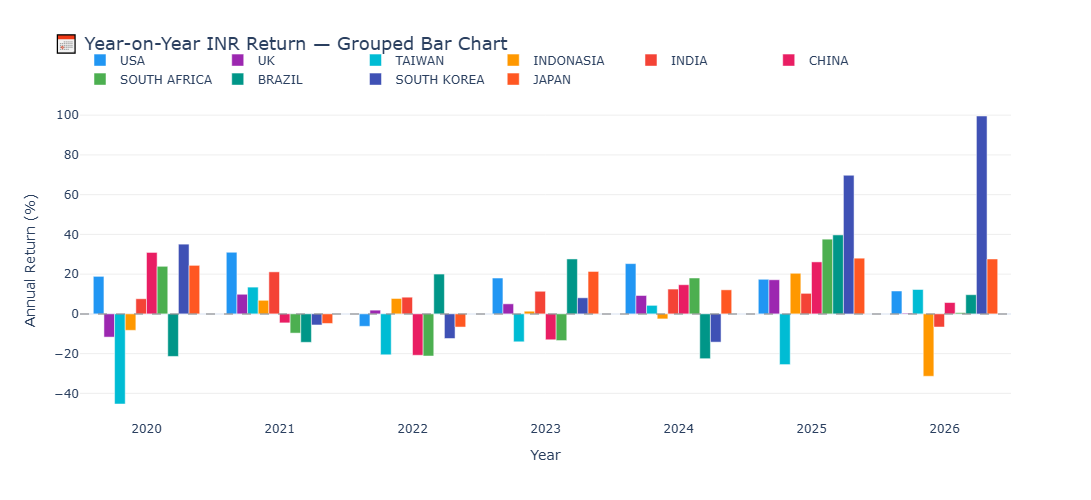

In [27]:
fig = go.Figure()

years = sorted(yearly_df['Year'].unique())
for country in COUNTRIES:
    ydata = yearly_df[yearly_df['Country'] == country].set_index('Year')['Annual_Return_Pct']
    fig.add_trace(go.Bar(
        name=country,
        x=[str(y) for y in years],
        y=[ydata.get(y, None) for y in years],
        marker_color=COUNTRY_COLORS[country]
    ))

fig.add_hline(y=0, line_dash='dash', line_color='gray', opacity=0.5)
fig.update_layout(
    title=dict(text='📅 Year-on-Year INR Return — Grouped Bar Chart', font=dict(size=18)),
    barmode='group',
    xaxis_title='Year',
    yaxis_title='Annual Return (%)',
    height=500,
    plot_bgcolor='rgba(0,0,0,0)',
    yaxis=dict(gridcolor='#eee'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02)
)
fig.show()

## 16. 📝 Final Summary & Conclusions

In [28]:
print('=' * 70)
print('📋  SUMMARY REPORT — GLOBAL MARKET ANALYSIS (Indian Investor View)')
print('=' * 70)

print('\n🏆  TOP 3 MARKETS BY TOTAL INR-ADJUSTED RETURN:')
top3 = summary_df.head(3)
for i, row in top3.iterrows():
    print(f"  {i+1}. {row['Country']:15s} → Total: {row['Total Return (%)']:+.1f}%  |  CAGR: {row['CAGR (%)']:.1f}%  |  Volatility: {row['Ann. Volatility (%)']:.1f}%")

print('\n💰  BEST RISK-ADJUSTED RETURN (Return/Risk Ratio):')
best_sharpe = summary_df.sort_values('Return/Risk', ascending=False).head(3)
for i, (_, row) in enumerate(best_sharpe.iterrows()):
    print(f"  {i+1}. {row['Country']:15s} → Return/Risk: {row['Return/Risk']:.2f}")

print('\n🔭  TOP 3 MARKETS FOR NEXT 6-12 MONTHS (2026 Outlook Score):')
top3_out = out_display.head(3)
for i, (_, row) in enumerate(top3_out.iterrows()):
    print(f"  {i+1}. {row['Country']:15s} → Score: {row['Outlook_Score']:.3f}  |  6M Momentum: {row['6M Momentum (%)']:+.1f}%  |  CAPE: {row['Latest CAPE']:.1f}")

print('\n📊  CHEAPEST MARKET BY CURRENT CAPE:')
cheapest = sorted(latest_cape.items(), key=lambda x: x[1])[:3]
for i, (c, v) in enumerate(cheapest):
    print(f'  {i+1}. {c:15s} → CAPE: {v:.1f}')

print('\n⚠️   NOTE: This is a data-driven quantitative analysis.')
print('     Always combine with qualitative research before investing.')
print('=' * 70)

📋  SUMMARY REPORT — GLOBAL MARKET ANALYSIS (Indian Investor View)

🏆  TOP 3 MARKETS BY TOTAL INR-ADJUSTED RETURN:
  1. SOUTH KOREA     → Total: +314.4%  |  CAGR: 24.8%  |  Volatility: 26.5%
  2. USA             → Total: +207.0%  |  CAGR: 19.1%  |  Volatility: 16.1%
  3. JAPAN           → Total: +156.7%  |  CAGR: 15.8%  |  Volatility: 20.4%

💰  BEST RISK-ADJUSTED RETURN (Return/Risk Ratio):
  1. USA             → Return/Risk: 1.19
  2. SOUTH KOREA     → Return/Risk: 0.93
  3. JAPAN           → Return/Risk: 0.78

🔭  TOP 3 MARKETS FOR NEXT 6-12 MONTHS (2026 Outlook Score):
  1. BRAZIL          → Score: 0.717  |  6M Momentum: +9.6%  |  CAPE: 9.3
  2. SOUTH KOREA     → Score: 0.644  |  6M Momentum: +99.6%  |  CAPE: 19.1
  3. UK              → Score: 0.612  |  6M Momentum: +0.4%  |  CAPE: 16.1

📊  CHEAPEST MARKET BY CURRENT CAPE:


AttributeError: 'numpy.float64' object has no attribute 'items'